In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
from tqdm import tqdm
from scipy import stats
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/sessions_14days.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Гипотеза 1: Существует ли разница в медианной цене товаров между сессиями с покупкой и без покупки?

=== ОПИСАТЕЛЬНАЯ СТАТИСТИКА ===
Группа 'ПОКУПКА' (purchase):
count   284,568
mean        317
std         340
min           1
25%          98
50%         191
75%         387
max       2,574
Name: avg_price, dtype: float64
Скошенность: 2.037

Группа 'НЕТ ПОКУПКИ' (purchase):
count   3,871,545
mean          320
std           354
min             1
25%            85
50%           192
75%           410
max         2,574
Name: avg_price, dtype: float64
Скошенность: 2.162


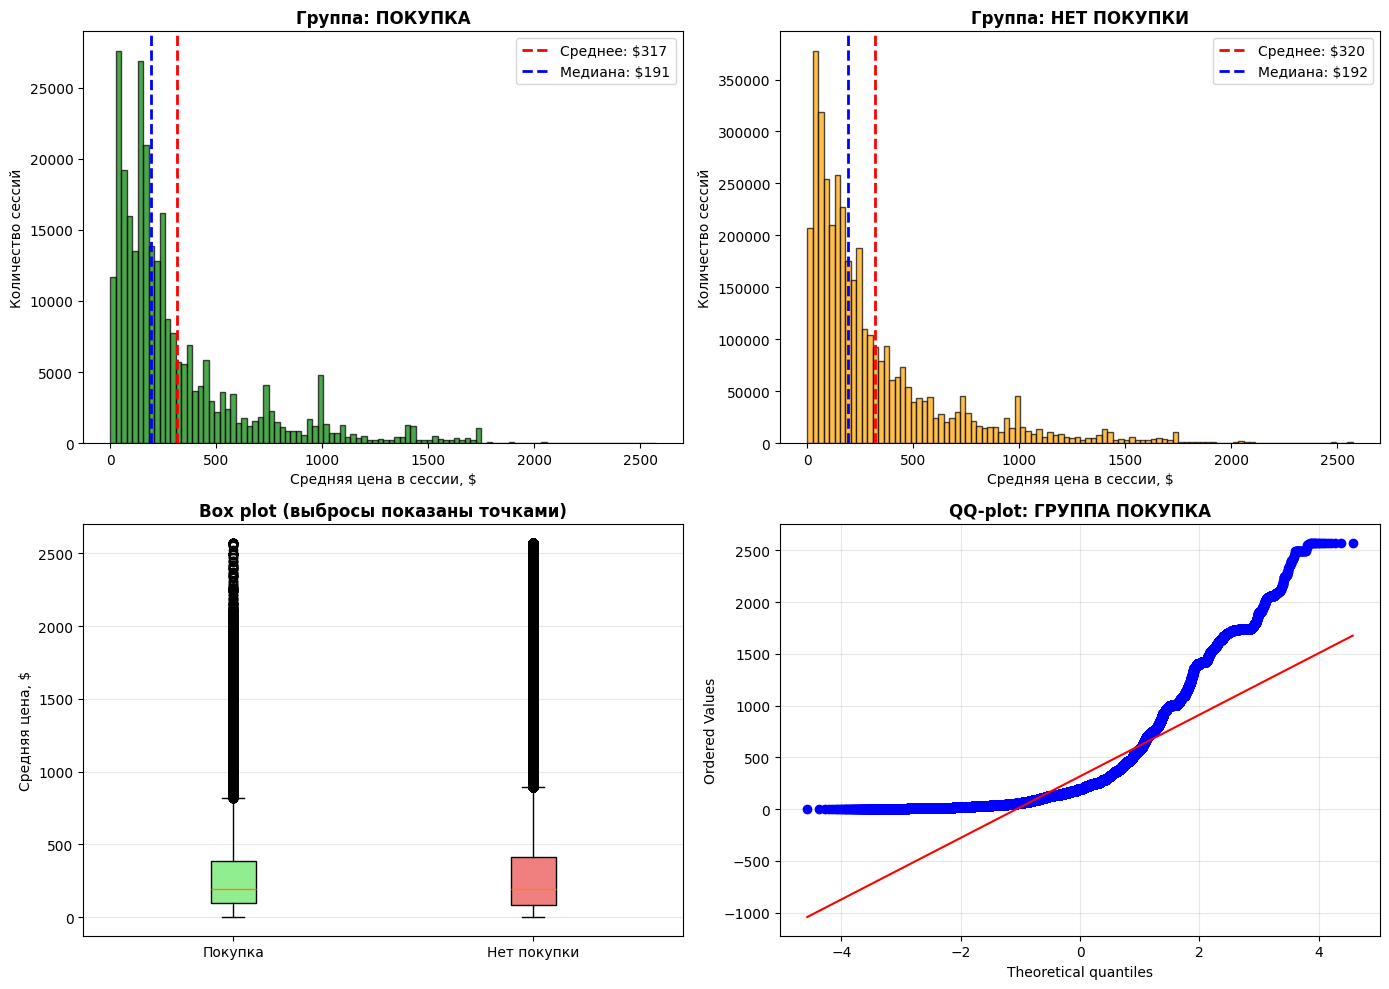

In [17]:
# Группировка данных
price_buy = df[df['made_purchase'] == 1]['avg_price'].dropna()
price_no_buy = df[df['made_purchase'] == 0]['avg_price'].dropna()
pd.options.display.float_format = '{:,.0f}'.format

print("=== ОПИСАТЕЛЬНАЯ СТАТИСТИКА ===")
print("Группа 'ПОКУПКА' (purchase):")
print(price_buy.describe())
print(f"Скошенность: {price_buy.skew():.3f}\n")

print("Группа 'НЕТ ПОКУПКИ' (purchase):")
print(price_no_buy.describe())
print(f"Скошенность: {price_no_buy.skew():.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма — покупка
axes[0, 0].hist(price_buy, bins=100, alpha=0.7, edgecolor='black', color='green')
axes[0, 0].axvline(price_buy.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: ${price_buy.mean():.0f}')
axes[0, 0].axvline(price_buy.median(), color='blue', linestyle='--', linewidth=2, label=f'Медиана: ${price_buy.median():.0f}')
axes[0, 0].set_title('Группа: ПОКУПКА', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Средняя цена в сессии, $')
axes[0, 0].set_ylabel('Количество сессий')
axes[0, 0].legend()


# Гистограмма — нет покупки
axes[0, 1].hist(price_no_buy, bins=100, alpha=0.7, edgecolor='black', color='orange')
axes[0, 1].axvline(price_no_buy.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: ${price_no_buy.mean():.0f}')
axes[0, 1].axvline(price_no_buy.median(), color='blue', linestyle='--', linewidth=2, label=f'Медиана: ${price_no_buy.median():.0f}')
axes[0, 1].set_title('Группа: НЕТ ПОКУПКИ', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Средняя цена в сессии, $')
axes[0, 1].set_ylabel('Количество сессий')
axes[0, 1].legend()



# Box plot

data_to_plot = [price_buy, price_no_buy]
bp = axes[1, 0].boxplot(data_to_plot, tick_labels=['Покупка', 'Нет покупки'], patch_artist=True)

colors = ['lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 0].set_title('Box plot (выбросы показаны точками)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Средняя цена, $')
axes[1, 0].grid(axis='y', alpha=0.3)


# QQ-plot

stats.probplot(price_buy, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ-plot: ГРУППА ПОКУПКА', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Для проверки гипотезы о различии цен между сессиями с покупкой и без покупки использовалась разность медиан, так как распределение цены скошено и содержит выбросы. Медиана более устойчива к асимметрии и лучше отражает типичную цену, чем среднее.


In [15]:
def bootstrap_median_diff(price_buy, price_no_buy, n_iterations=5000, seed=42):
    """
    Bootstrap для разности медиан (Покупка - Нет покупки)
    """
    np.random.seed(seed)

    # Убираем NaN
    group1 = np.asarray(price_buy.dropna())
    group2 = np.asarray(price_no_buy.dropna())

    # Наблюдаемая разница медиан
    observed_diff = np.median(group1) - np.median(group2)

    # Bootstrap распределение разности медиан
    bootstrap_diffs = np.zeros(n_iterations)

    for i in tqdm(range(n_iterations), desc="Bootstrap итераций"):
        # Ресэмплируем каждую группу
        sample1 = np.random.choice(group1, size=len(group1), replace=True)
        sample2 = np.random.choice(group2, size=len(group2), replace=True)

        # Разность медиан
        bootstrap_diffs[i] = np.median(sample1) - np.median(sample2)

    # 95% ДИ для разности медиан
    ci_low, ci_high = np.percentile(bootstrap_diffs, [2.5, 97.5])

    # p-value (двусторонний тест)
    p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))

    return {
        'observed_diff': observed_diff,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'p_value': p_value,
        'bootstrap_diffs': bootstrap_diffs
    }

# Запуск
result = bootstrap_median_diff(price_buy, price_no_buy, n_iterations=3000)

print(f"Наблюдаемая разность медиан:  ${result['observed_diff']:.0f}")
print(f"95% ДИ для разности:          [${result['ci_low']:.0f}, ${result['ci_high']:.0f}]")
print(f"p-value (bootstrap):          {result['p_value']:.4f}")

if result['p_value'] < 0.05:
    print("Результат статистически значим")
    if 0 not in [result['ci_low'], result['ci_high']]:
        print("ДИ не включает 0 → устойчивое различие")
    else:
        print("ДИ включает 0 → различие неустойчиво")
else:
    print("Разница не статистически значима")
print(f"  Покупка:  n={len(price_buy.dropna()):,} | медиана=${np.median(price_buy.dropna()):.0f}")
print(f"  Нет покупки: n={len(price_no_buy.dropna()):,} | медиана=${np.median(price_no_buy.dropna()):.0f}")

Bootstrap итераций: 100%|██████████| 3000/3000 [07:56<00:00,  6.29it/s]


Наблюдаемая разность медиан:  $-1
95% ДИ для разности:          [$-2, $0]
p-value (bootstrap):          0.5123
Разница не статистически значима
  Покупка:  n=284,568 | медиана=$191
  Нет покупки: n=3,871,545 | медиана=$192


"Существует ли разница в средней цене товаров между сессиями, завершившимися покупкой, и сессиями без покупки?"

При огромных выборках любое, даже минимальное, отклонение становится "значимым". Правильный вопрос не "есть ли разница", а "насколько велика эта разница".

In [16]:
# Welch t-test (не требует равенства дисперсий)
t_stat, p_value_welch = stats.ttest_ind(
    price_buy.dropna(),
    price_no_buy.dropna(),
    equal_var=False  # Welch версия
)

print(f"t-статистика:    {t_stat:.3f}")
print(f"p-value:         {p_value_welch:.2e}")
print(f"df (примерно):   ~284k")  # из-за огромной выборки

if p_value_welch < 0.05:
    print("Статистически значимо")
else:
    print("Не значимо")

print(f"\nРазница средних:  ${np.mean(price_buy.dropna()) - np.mean(price_no_buy.dropna()):.2f}")

#Cohen's d для двух выборок (Welch)
mean_diff = np.mean(price_buy.dropna()) - np.mean(price_no_buy.dropna())
sd_buy = np.std(price_buy.dropna(), ddof=1)
sd_no_buy = np.std(price_no_buy.dropna(), ddof=1)

# Пуллированная стандартная ошибка (по правилу Welch)
pooled_sd = np.sqrt((sd_buy**2 + sd_no_buy**2) / 2)
cohens_d = mean_diff / pooled_sd

print(f"Cohen's d: {cohens_d:.3f}")


t-статистика:    -4.319
p-value:         1.56e-05
df (примерно):   ~284k
Статистически значимо

Разница средних:  $-2.86
Cohen's d: -0.008


Cohen's указывает на тривиальный размер эффекта.Разница статистически значима из-за гигантской выборки, но практическая значимость отсутствует.

ДОЛИ ПО ЦЕНОВЫМ СЕГМЕНТАМ (%):
price_segment  бюджетный  средний  премиум  высокий премиум  люкс
нет покупки           29       23       29               13     6
покупка               25       26       29               13     6

Chi-square тест: chi2=3034.20, p-value=0.0000, df=4


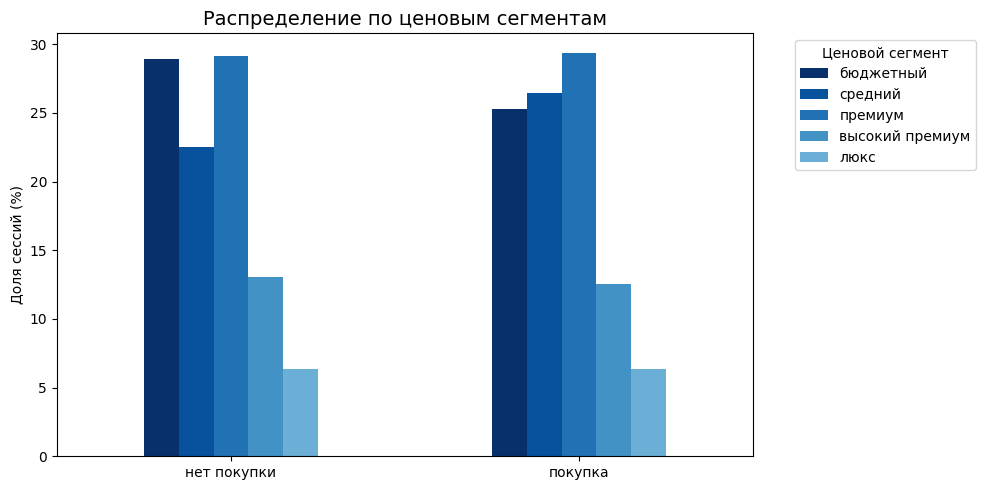

In [33]:
# Фиксированные ценовые пороги (бизнес-логика + квартили)
price_segments = {
    'бюджетный': (0, 100),
    'средний': (100, 200),
    'премиум': (200, 500),
    'высокий премиум': (500, 1000),
    'люкс': (1000, float('inf'))
}

def get_price_segment(price):
    for segment, (low, high) in price_segments.items():
        if low <= price < high:
            return segment
    return 'люкс'

df['price_segment'] = df['avg_price'].apply(get_price_segment)

# Таблица с подписями групп
crosstab = pd.crosstab(
    df['made_purchase'],
    df['price_segment'],
    normalize='index'
) * 100

# Индексы
crosstab.index = ['нет покупки', 'покупка']

# Сортировка
segment_order = ['бюджетный', 'средний', 'премиум', 'высокий премиум', 'люкс']
crosstab = crosstab[segment_order]

print("ДОЛИ ПО ЦЕНОВЫМ СЕГМЕНТАМ (%):")
print(crosstab.round(2))

# Chi-square
chi2, p_chi, dof, expected = stats.chi2_contingency(
    pd.crosstab(df['made_purchase'], df['price_segment'])
)
print(f"\nChi-square тест: chi2={chi2:.2f}, p-value={p_chi:.4f}, df={dof}")


crosstab.plot(kind='bar', figsize=(10, 5), color = ['#08306b', '#08519c', '#2171b5', '#4292c6', '#6baed6'])
plt.title('Распределение по ценовым сегментам', fontsize=14)
plt.ylabel('Доля сессий (%)')
plt.xlabel('')
plt.legend(title='Ценовой сегмент', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Статистически: значимо
Практически: эффект слабый (Δ=±3-4%)

Ключевые выводы:
- Бюджетный (-4%): покупатели реже
- Средний (+3%): покупатели чаще  
- Премиум/люкс: без разницы

Бизнес-рекомендация: слабая тенденция к среднему сегменту